## This uses Dython in order to simulate a similar Associations -tool as in SweetViz

**This tool is optional, but can be used if you don't wish to install SweetViz**

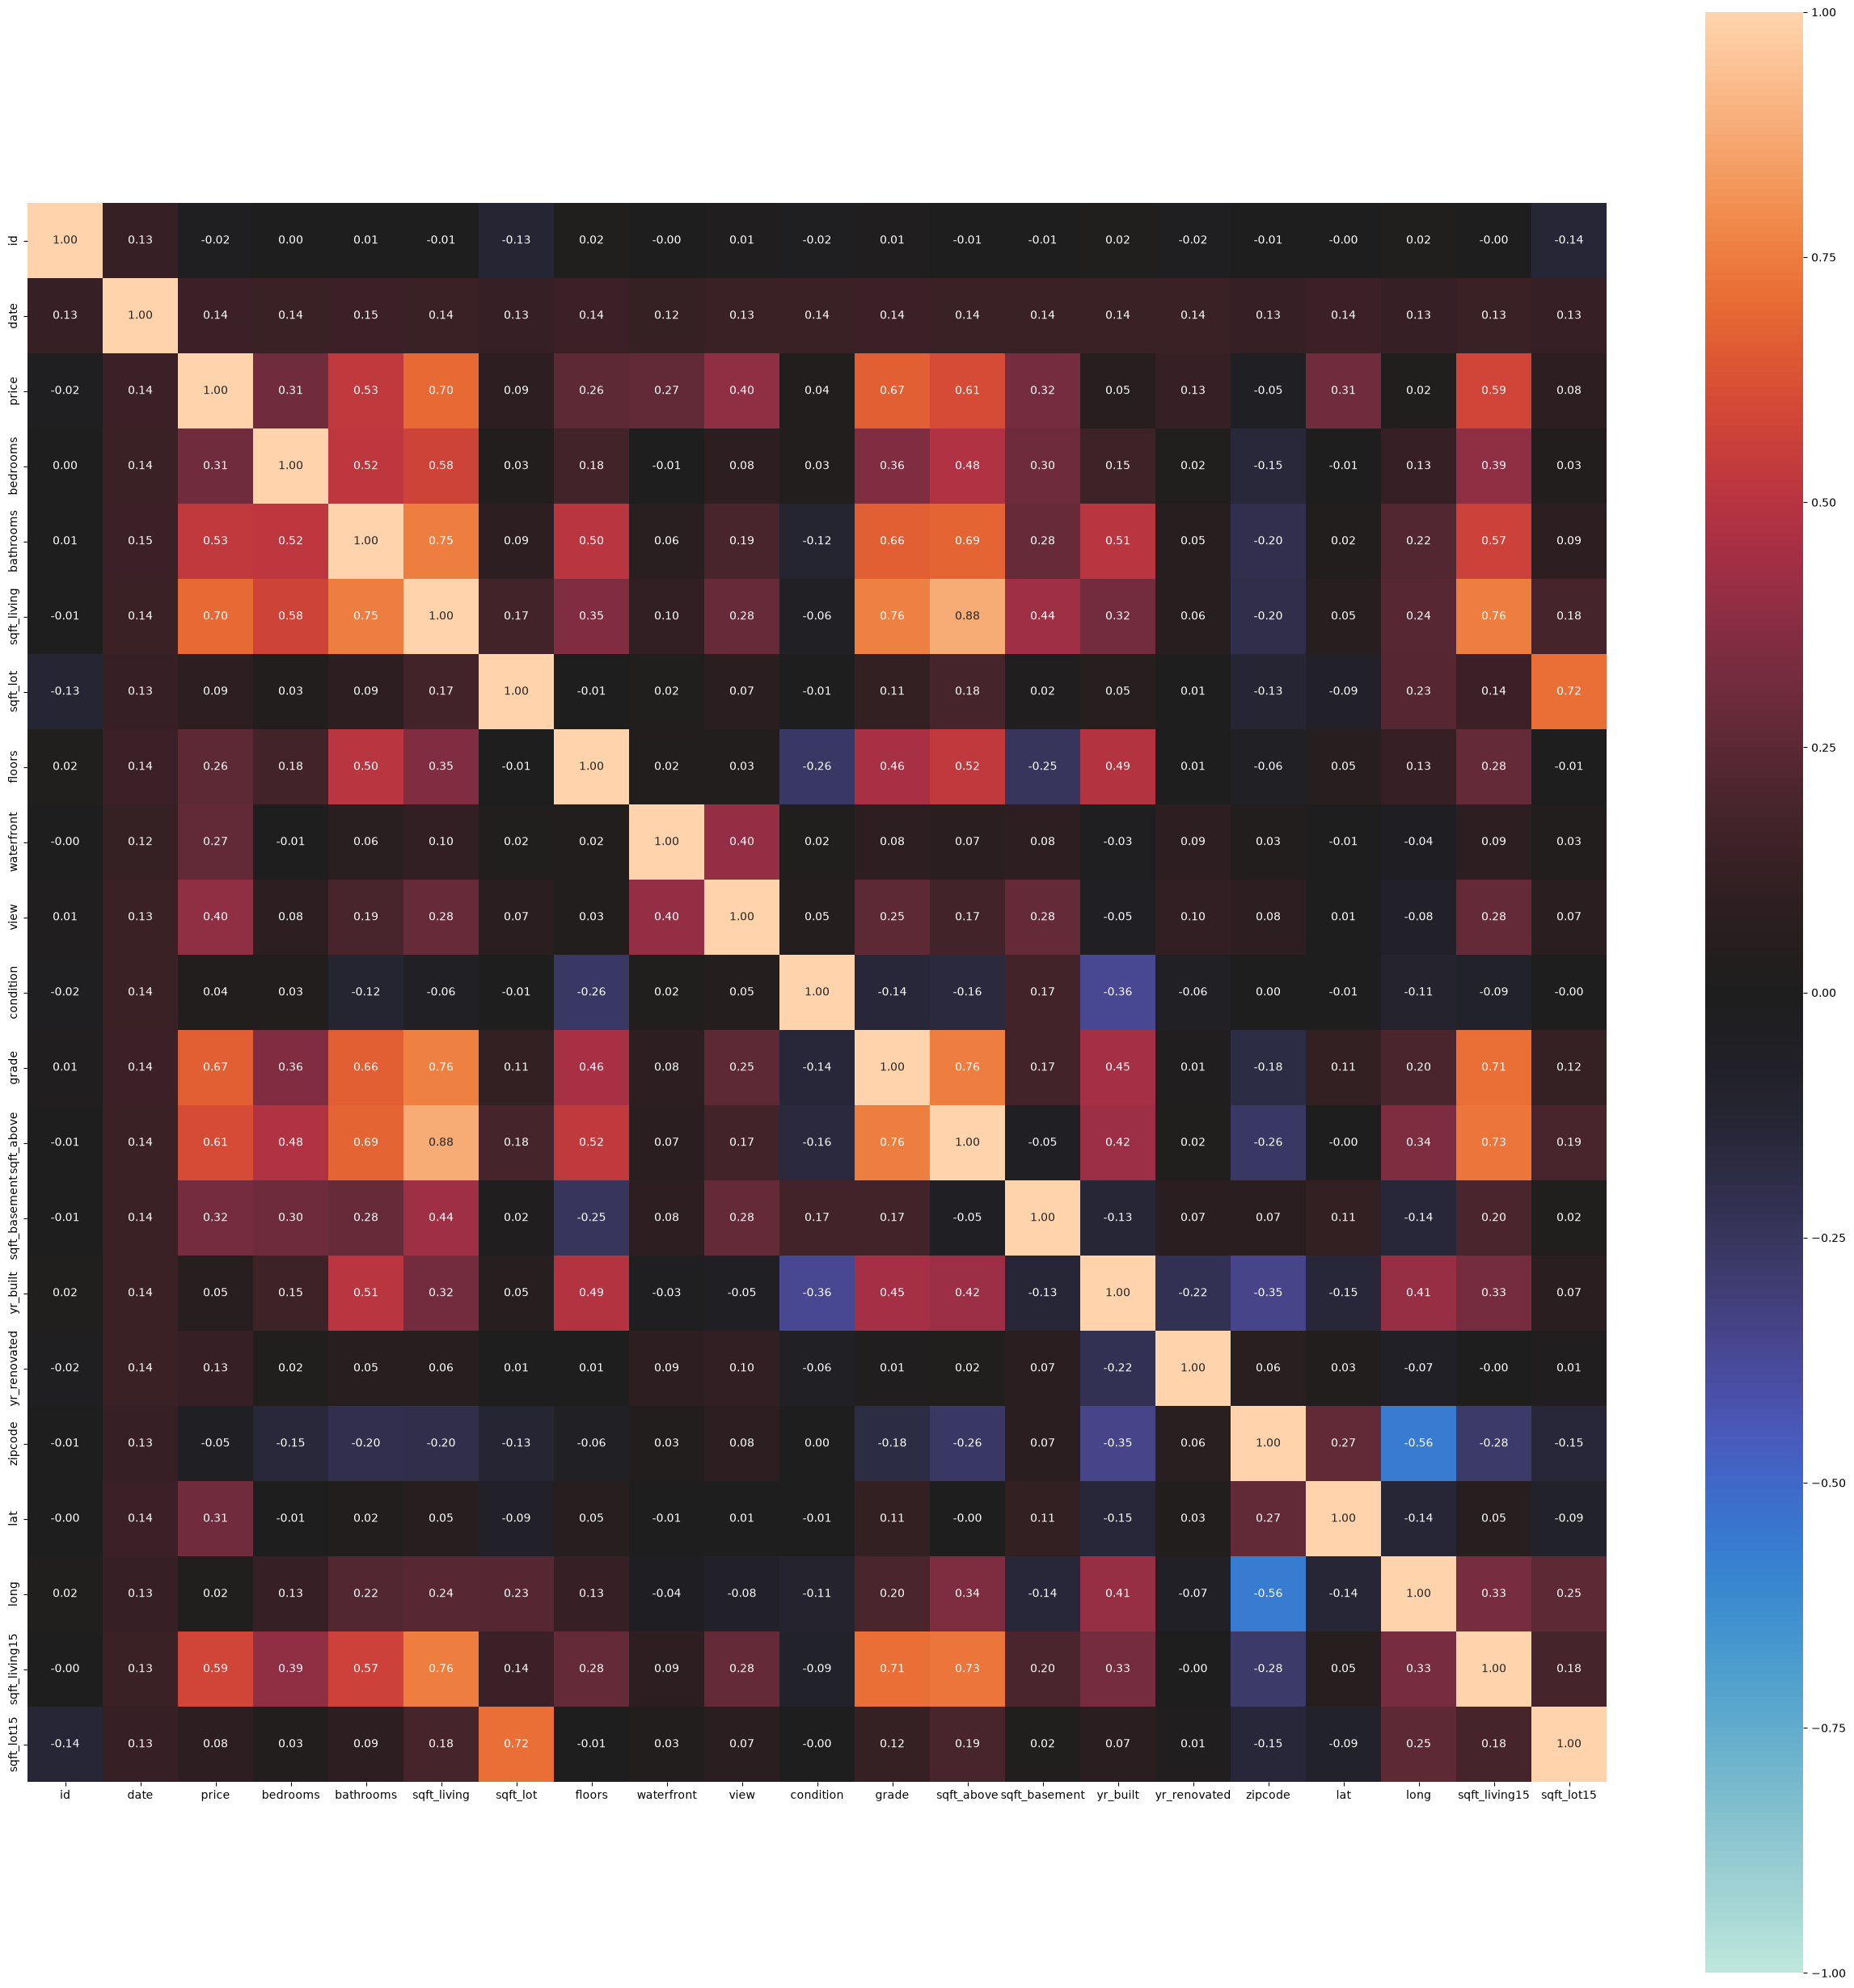

<Axes: >

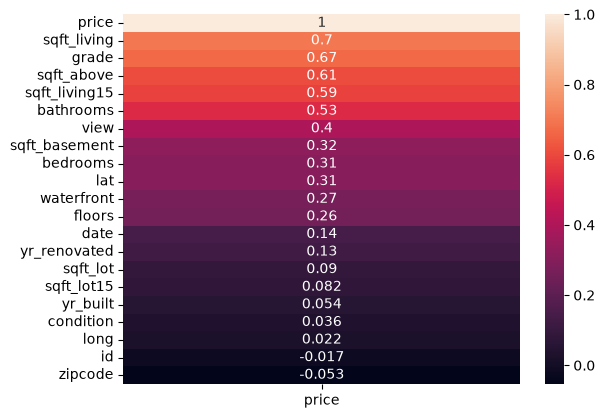

In [2]:
# pip install dython
# pip install phik
from dython.nominal import associations
import pandas as pd
import seaborn as sns
import phik

# Load the desired csv into a pandas dataframe.
df = pd.read_csv("../houses_fixed.csv")

# Create the associations matrix, don't output the visual.
# Also, set rules for using the optimal correlation/association metric.
assoc = associations(
    df,
    nominal_columns='auto',
    nom_nom_assoc='theil',              # nominal vs nominal
    num_num_assoc='pearson',            # continuous vs continuous
    nom_num_assoc='correlation_ratio',  # nominal vs continuous
    plot=True
)

# for column specific plot
TARGET_VARIABLE = "price"

# Retrieve only the correlations and place it into a pandas dataframe.
assoc_df = pd.DataFrame(assoc["corr"])

# Filter, and create a heatmap.
assoc_df = assoc_df[[TARGET_VARIABLE]].sort_values(by=TARGET_VARIABLE, ascending=False)
sns.heatmap(assoc_df, annot=True)